# Hello, MNIST!

Let's extend [Hello, World!](hello-world.ipynb) to an actual learning problem: MNIST! First, we download the data.

In [1]:
from data.mnist import load_mnist

# Load the MNIST dataset
train_images, train_labels, test_images, test_labels = load_mnist()

# Print shapes to verify loading
print(f"Training images shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


Next, let's plot a few training points.

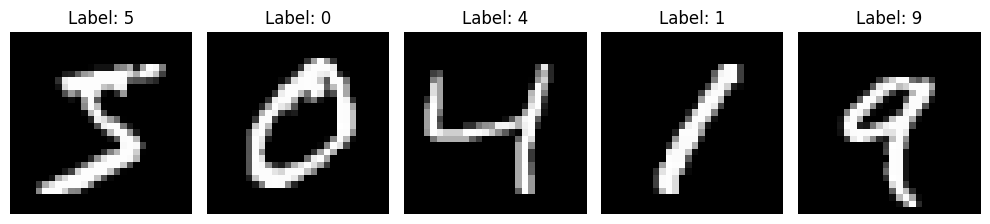

In [2]:
import matplotlib.pyplot as plt

# Create a figure with 5 subplots
fig, axes = plt.subplots(1, 5, figsize=(10, 3))

# Plot each image and its label
for i in range(5):
    axes[i].imshow(train_images[i], cmap='gray')
    axes[i].set_title(f'Label: {train_labels[i]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Now we flatten the inputs into vectors, encode the targets as one-hot vectors, and write a mini-batch sampler.

In [3]:
import jax
import jax.numpy as jnp

X_train = jnp.reshape(train_images, (-1, 28, 28, 1))
y_train = train_labels

# Getting a batch like this results in horrible performance!
# def get_batch(key, batch_size):
#     idx = jax.random.choice(key, X_train.shape[1], shape=(batch_size,))
#     return X_train[idx, :], y_train[idx]

def stream(batch_size):
    num_samples = X_train.shape[0]
    while True:
        key = jax.random.PRNGKey(0)
        perm = jax.random.permutation(key, num_samples)
        for i in range(num_samples // batch_size):
            indices = perm[i * batch_size:(i + 1) * batch_size]
            yield X_train[indices], y_train[indices]

Now we're ready to build our ViT.

In [4]:
from modula.compound import ViT

input_dim = X_train.shape[1:-1]
output_dim = 10

vit = ViT(output_dim, image_size=input_dim, patch_size=(7, 7), num_heads=8, d_embed=64, d_query=8, d_value=8, num_blocks=3, blocks_mass=6, attention_scale=1.0, final_scale=1.0)

print(vit)

vit.jit()

CompositeModule
...consists of 54 atoms and 91 bonds
...non-smooth
...input sensitivity is 51.72763417352536
...contributes proportion 12.0 to feature learning of any supermodule


Let's train the MLP for 1000 steps.

In [5]:
from tqdm.notebook import tqdm

def cross_entropy_loss(w, inputs, targets):
    # We use the logsumexp trick for stable cross entropy
    logits = vit(inputs, w)  # shape is [batch, num_classes]
    batch_indices = jnp.arange(logits.shape[0])
    losses = -logits[batch_indices, targets] + jax.nn.logsumexp(logits, axis=-1)
    return losses.mean()

loss_and_grad = jax.jit(jax.value_and_grad(cross_entropy_loss))

In [6]:
batch_size = 128
steps = 1000
learning_rate = 0.05
s = stream(batch_size)

key = jax.random.PRNGKey(0)
w = vit.initialize(key)

momentum = [0 * weight for weight in w]
beta = 0.99

progress_bar = tqdm(range(steps), desc=f"Loss: {0:.4f}")
for step in progress_bar:
    inputs, targets = next(s)
    loss, grad_w = loss_and_grad(w, inputs, targets)
    momentum = [beta * m + (1 - beta) * g_w for m, g_w in zip(momentum, grad_w)]

    d_w = vit.dualize(momentum)
    w = [weight - learning_rate * d_weight for weight, d_weight in zip(w, d_w)]
    progress_bar.set_description(f"Loss: {loss:.4f}")

Loss: 0.0000:   0%|          | 0/1000 [00:00<?, ?it/s]

And finally let's plot some test predictions.

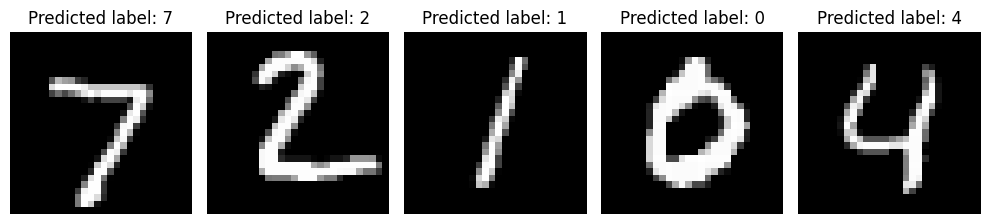

Accuracy on shown samples: 5/5
Overall test accuracy: 94.69%


In [7]:
# Get predictions for test images
X_test = jnp.reshape(test_images, (-1, 28, 28, 1))
test_outputs = vit(X_test, w)
predicted_labels = jnp.argmax(test_outputs, axis=1)

# Create a figure with subplots for multiple test images
n_samples = 5  # Number of test images to display
fig, axes = plt.subplots(1, n_samples, figsize=(10, 3))

# Plot each test image with predicted labels
for i in range(n_samples):
    axes[i].imshow(test_images[i], cmap='gray')
    axes[i].set_title(f'Predicted label: {int(predicted_labels[i])}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Print accuracy for these samples
correct = (predicted_labels[:n_samples] == test_labels[:n_samples]).sum()
print(f"Accuracy on shown samples: {correct}/{n_samples}")

# Calculate and print overall test accuracy
total_correct = (predicted_labels == test_labels).sum()
total_samples = len(test_labels)
print(f"Overall test accuracy: {100 * total_correct/total_samples:.2f}%")

In [8]:
# Barebone without bias or LN
# vit = ViT(output_dim, image_size=input_dim, patch_size=(7, 7), num_heads=8, d_embed=64, d_query=8, d_value=8, num_blocks=3, blocks_mass=6, attention_scale=1.0, final_scale=1.0, LN=False, bias=False, scale=False)
# Just LN, no bias or scale
# vit = ViT(output_dim, image_size=input_dim, patch_size=(7, 7), num_heads=8, d_embed=64, d_query=8, d_value=8, num_blocks=3, blocks_mass=6, attention_scale=1.0, final_scale=1.0, LN=True, bias=False, scale=False)
# Both would diverge

In [9]:
# No LN or scale, just bias:
vit = ViT(output_dim, image_size=input_dim, patch_size=(7, 7), num_heads=8, d_embed=64, d_query=8, d_value=8, num_blocks=3, blocks_mass=6, attention_scale=1.0, final_scale=1.0, LN=False, bias=True, scale=False)

print(vit)

vit.jit()

CompositeModule
...consists of 40 atoms and 77 bonds
...non-smooth
...input sensitivity is 2.84765625
...contributes proportion 10.0 to feature learning of any supermodule


In [10]:
batch_size = 128
steps = 1000
learning_rate = 0.05
s = stream(batch_size)

key = jax.random.PRNGKey(0)
w = vit.initialize(key)

momentum = [0 * weight for weight in w]
beta = 0.99

progress_bar = tqdm(range(steps), desc=f"Loss: {0:.4f}")
for step in progress_bar:
    inputs, targets = next(s)
    loss, grad_w = loss_and_grad(w, inputs, targets)
    momentum = [beta * m + (1 - beta) * g_w for m, g_w in zip(momentum, grad_w)]

    d_w = vit.dualize(momentum)
    w = [weight - learning_rate * d_weight for weight, d_weight in zip(w, d_w)]
    progress_bar.set_description(f"Loss: {loss:.4f}")

Loss: 0.0000:   0%|          | 0/1000 [00:00<?, ?it/s]

In [11]:
test_outputs = vit(X_test, w)
predicted_labels = jnp.argmax(test_outputs, axis=1)

# Calculate and print overall test accuracy
total_correct = (predicted_labels == test_labels).sum()
total_samples = len(test_labels)
print(f"Overall test accuracy: {100 * total_correct/total_samples:.2f}%")

Overall test accuracy: 87.63%


It works but not nearly as well

In [12]:
# LN and bias, no scale works fine though:
vit = ViT(output_dim, image_size=input_dim, patch_size=(7, 7), num_heads=8, d_embed=64, d_query=8, d_value=8, num_blocks=3, blocks_mass=6, attention_scale=1.0, final_scale=1.0, LN=True, bias=True, scale=False)

print(vit)

vit.jit()

CompositeModule
...consists of 47 atoms and 91 bonds
...non-smooth
...input sensitivity is 51.72763417352536
...contributes proportion 11.0 to feature learning of any supermodule


In [13]:
batch_size = 128
steps = 1000
learning_rate = 0.05
s = stream(batch_size)

key = jax.random.PRNGKey(0)
w = vit.initialize(key)

momentum = [0 * weight for weight in w]
beta = 0.99

progress_bar = tqdm(range(steps), desc=f"Loss: {0:.4f}")
for step in progress_bar:
    inputs, targets = next(s)
    loss, grad_w = loss_and_grad(w, inputs, targets)
    momentum = [beta * m + (1 - beta) * g_w for m, g_w in zip(momentum, grad_w)]

    d_w = vit.dualize(momentum)
    w = [weight - learning_rate * d_weight for weight, d_weight in zip(w, d_w)]
    progress_bar.set_description(f"Loss: {loss:.4f}")

Loss: 0.0000:   0%|          | 0/1000 [00:00<?, ?it/s]

In [14]:
# Get predictions for test images
test_outputs = vit(X_test, w)
predicted_labels = jnp.argmax(test_outputs, axis=1)

# Calculate and print overall test accuracy
total_correct = (predicted_labels == test_labels).sum()
total_samples = len(test_labels)
print(f"Overall test accuracy: {100 * total_correct/total_samples:.2f}%")

Overall test accuracy: 95.21%


In [15]:
batch_size = 128
steps = 1000
learning_rate = 0.003
s = stream(batch_size)

key = jax.random.PRNGKey(0)
w = vit.initialize(key)

# From scratch implementation of Adam, without correction:
momentum = [0 * weight for weight in w]
second = [0 * weight for weight in w]
beta1 = 0.9
beta2 = 0.999
eps = 1e-8

progress_bar = tqdm(range(steps), desc=f"Loss: {0:.4f}")
for step in progress_bar:
    key = jax.random.PRNGKey(step)
    inputs, targets = next(s)
    loss, grad_w = loss_and_grad(w, inputs, targets)
    momentum = [beta1 * m + (1 - beta1) * g_w for m, g_w in zip(momentum, grad_w)]
    second = [beta2 * s + (1 - beta2) * g_w ** 2 for s, g_w in zip(second, grad_w)]

    # d_w = vit.dualize(grad_w)
    w = [weight - learning_rate * m / (s ** 0.5 + eps) for weight, m, s in zip(w, momentum, second)]
    progress_bar.set_description(f"Loss: {loss:.4f}")

Loss: 0.0000:   0%|          | 0/1000 [00:00<?, ?it/s]

In [16]:
# Get predictions for test images
test_outputs = vit(X_test, w)
predicted_labels = jnp.argmax(test_outputs, axis=1)

# Calculate and print overall test accuracy
total_correct = (predicted_labels == test_labels).sum()
total_samples = len(test_labels)
print(f"Overall test accuracy: {100 * total_correct/total_samples:.2f}%")

Overall test accuracy: 93.46%


In [17]:
batch_size = 128
steps = 1000
learning_rate = 0.001
s = stream(batch_size)

key = jax.random.PRNGKey(0)
w = vit.initialize(key)

# From scratch implementation of Adam, without correction:
momentum = [0 * weight for weight in w]
second = [0 * weight for weight in w]
beta1 = 0.9
beta2 = 0.999
eps = 1e-8

progress_bar = tqdm(range(steps), desc=f"Loss: {0:.4f}")
for step in progress_bar:
    key = jax.random.PRNGKey(step)
    inputs, targets = next(s)
    loss, grad_w = loss_and_grad(w, inputs, targets)
    momentum = [beta1 * m + (1 - beta1) * g_w for m, g_w in zip(momentum, grad_w)]
    second = [beta2 * s + (1 - beta2) * g_w ** 2 for s, g_w in zip(second, grad_w)]

    # d_w = vit.dualize(grad_w)
    w = [weight - learning_rate * m / (s ** 0.5 + eps) for weight, m, s in zip(w, momentum, second)]
    progress_bar.set_description(f"Loss: {loss:.4f}")

Loss: 0.0000:   0%|          | 0/1000 [00:00<?, ?it/s]

In [18]:
# Get predictions for test images
test_outputs = vit(X_test, w)
predicted_labels = jnp.argmax(test_outputs, axis=1)

# Calculate and print overall test accuracy
total_correct = (predicted_labels == test_labels).sum()
total_samples = len(test_labels)
print(f"Overall test accuracy: {100 * total_correct/total_samples:.2f}%")

Overall test accuracy: 96.81%


In [19]:
batch_size = 128
steps = 1000
learning_rate = 0.0005
s = stream(batch_size)

key = jax.random.PRNGKey(0)
w = vit.initialize(key)

# From scratch implementation of Adam, without correction:
momentum = [0 * weight for weight in w]
second = [0 * weight for weight in w]
beta1 = 0.9
beta2 = 0.999
eps = 1e-8

progress_bar = tqdm(range(steps), desc=f"Loss: {0:.4f}")
for step in progress_bar:
    key = jax.random.PRNGKey(step)
    inputs, targets = next(s)
    loss, grad_w = loss_and_grad(w, inputs, targets)
    momentum = [beta1 * m + (1 - beta1) * g_w for m, g_w in zip(momentum, grad_w)]
    second = [beta2 * s + (1 - beta2) * g_w ** 2 for s, g_w in zip(second, grad_w)]

    # d_w = vit.dualize(grad_w)
    w = [weight - learning_rate * m / (s ** 0.5 + eps) for weight, m, s in zip(w, momentum, second)]
    progress_bar.set_description(f"Loss: {loss:.4f}")

Loss: 0.0000:   0%|          | 0/1000 [00:00<?, ?it/s]

In [20]:
# Get predictions for test images
test_outputs = vit(X_test, w)
predicted_labels = jnp.argmax(test_outputs, axis=1)

# Calculate and print overall test accuracy
total_correct = (predicted_labels == test_labels).sum()
total_samples = len(test_labels)
print(f"Overall test accuracy: {100 * total_correct/total_samples:.2f}%")

Overall test accuracy: 95.47%


So LR = 1e-3 and 96.8 top-1 accuracy is probably about as good as it gets.
Now deleted but more conventional initialization with std = sqrt(1 / fanin) seems to have little effect.